# ORCC year 2 mass analysis

### This analysis examines oyster mass at a single time point one year (2025) after exposure (2024)

In [2]:
#load packages
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(tidyr)
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
#set contrasts ALWAYS RUN
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [4]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Weight_Data")

Year2_Growth <- read_csv("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Year_2_Data/growth_YEAR2_weights_merged.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor(),
                                              double_single_dead_year2 = col_factor()))

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

New names:
• `` -> `...1`


In [5]:
Year2_Growth_clean <- Year2_Growth %>%
  drop_na(Actual_tissue_growth_year2_mg) %>%
  filter(Exclude_year2 != "Y" | is.na(Exclude_year2)) %>%
  filter(!is.na(Phase_1_treat) & Phase_1_treat != "NA") %>%
  mutate(
    Actual_tissue_growth_year2_mg = as.numeric(Actual_tissue_growth_year2_mg),
    Actual_shell_growth_year2_mg = as.numeric(Actual_shell_growth_year2_mg),
    Ratio_TS_year2 = as.numeric(Ratio_TS_year2))

head(Year2_Growth_clean)

...1,Sample_Name,Phase_1_DO,Phase_1_temp,Phase_2.1_DO,Phase_2.1_temp,Phase_1_treat,Phase_2_treat,Phase_1_rep_R,Phase_2_rep_R,⋯,Submerged_weight_year2,Dry_weight_year2,double_single_dead_year2,Notes_year2,Actual_shell_year2_mg,Actual_tissue_year2_mg,Actual_shell_growth_year2_mg,Actual_tissue_growth_year2_mg,Ratio_TS_year2,Exclude_year2
<dbl>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,2024_Both01_Both02_O14,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both02,⋯,517.1,1309.3,NA,NA,816.4478,492.8522,161.0318,125.96822,0.7822569,NA
3,2024_Both01_Both03_O26,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both03,⋯,797.2,1828.7,NA,NA,1259.9582,568.7418,799.4587,368.54134,0.4609886,NA
4,2024_Both01_Both05_O49,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,726.4,1811.5,NA,NA,1147.8535,663.6465,529.3306,334.26938,0.6314945,NA
5,2024_Both01_Both05_O50,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,726.2,1682.6,NA,NA,1147.5368,535.0632,437.3351,181.36492,0.4147047,NA
6,2024_Both01_Both06_O61,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both06,⋯,346.2,799.6,NA,NA,545.8448,253.7552,254.6107,57.48928,0.2257928,NA
8,2024_Both01_Cont02_O13,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont02,⋯,1309.1,3109.3,NA,NA,2070.5006,1038.7994,929.1391,566.36088,0.6095544,NA


# 1. Tissue Mass

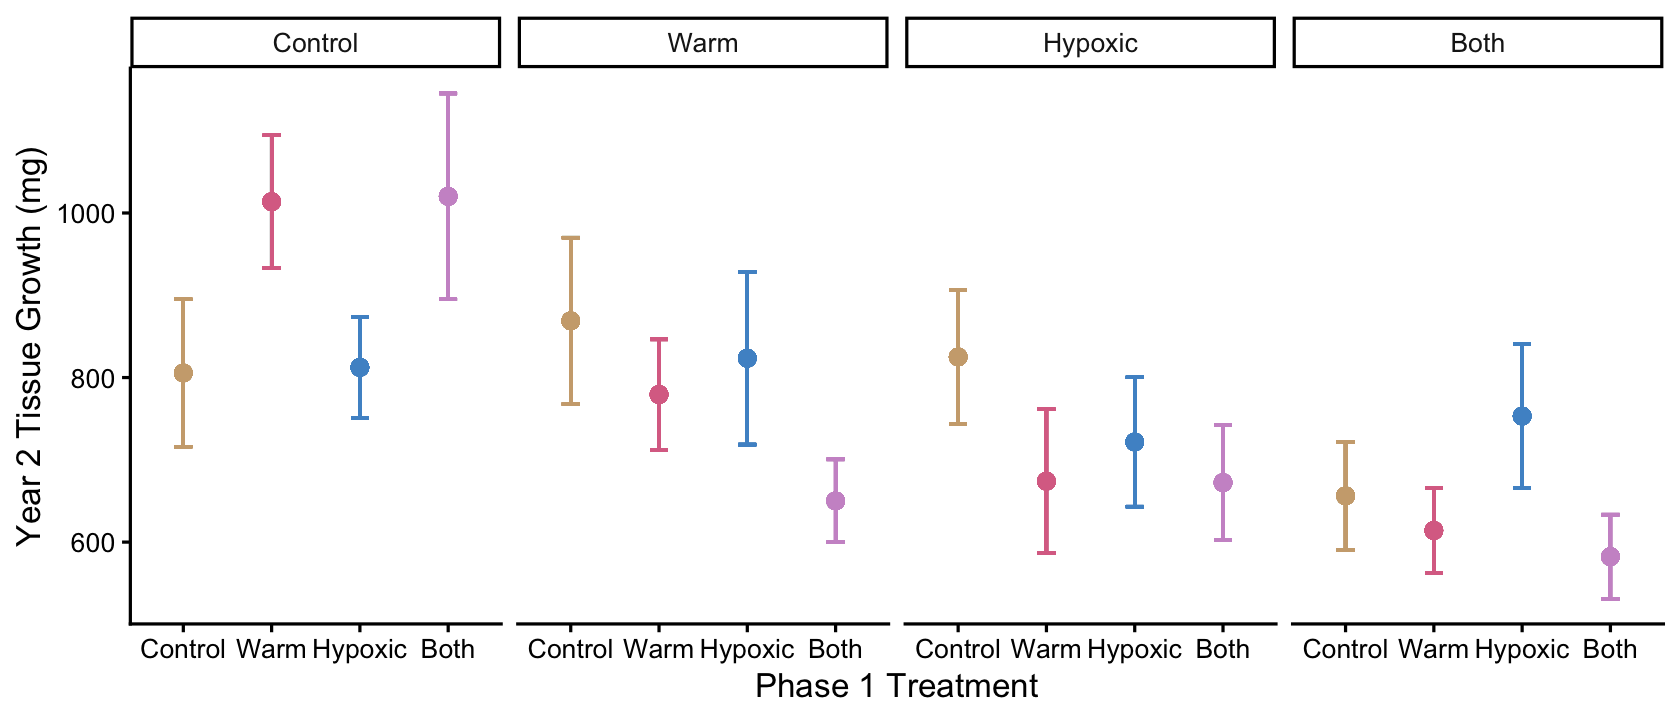

In [6]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_year2_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Tissue Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

In [7]:
##tissue growth (mg)
m1 <- lmer(Actual_tissue_year2_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
aov_tab <- Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),288.76564832,1,20.95658,0.0000
Phase_1_DO,0.28724255,1,13.61472,0.6006
Phase_1_temp,0.56409402,1,12.48645,0.4665
Phase_2.1_temp,1.09222803,1,19.55637,0.3087
Phase_2.1_DO,3.11425037,1,19.58038,0.0932
Phase_1_DO:Phase_1_temp,0.15286036,1,12.52762,0.7024
Phase_1_DO:Phase_2.1_temp,0.01214555,1,18.65320,0.9134
Phase_1_temp:Phase_2.1_temp,5.63697219,1,18.59633,0.0285
Phase_1_DO:Phase_2.1_DO,0.13073060,1,18.72496,0.7217


In [9]:
#posthocs
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Hyp             689 62.0 20.3      560      818
 Norm            843 63.5 20.8      711      975

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm     -154 87.4 19.6  -1.765  0.0932

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


In [20]:
(843-689)/843

[1] 0.1826809

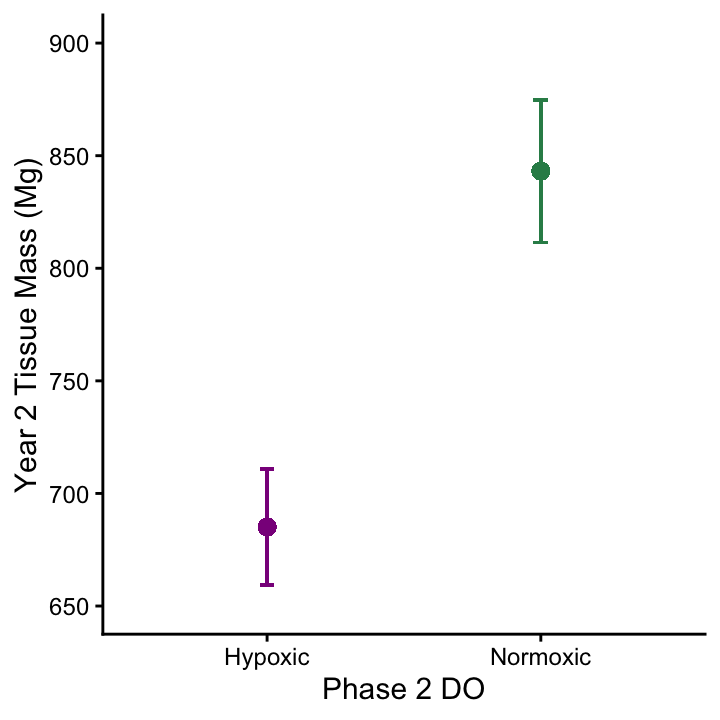

In [22]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#summary stats
summary_stats <- Year2_Growth_clean %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean(Actual_tissue_year2_mg, na.rm = TRUE),
    se = std.error(Actual_tissue_year2_mg, na.rm = TRUE))
#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Year 2 Tissue Mass (Mg)") +
scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
ylim(650, 900)+
  theme(legend.position = "none") # Remove legend

In [21]:
(781-660)/781

[1] 0.1549296

In [10]:
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp emmean   SE   df lower.CL upper.CL
 Warm         Warm              660 67.8 26.9      521      799
 Ambient      Warm              781 67.7 26.8      642      920
 Warm         Ambient           839 69.6 27.8      697      982
 Ambient      Ambient           784 70.7 29.5      639      928

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                       estimate   SE   df t.ratio p.value
 Warm Warm - Ambient Warm        -120.62 55.7 17.5  -2.166  0.0444
 Warm Warm - Warm Ambient        -179.33 94.5 25.9  -1.898  0.0688
 Warm Warm - Ambient Ambient     -123.81 97.9 28.2  -1.265  0.2163
 Ambient Warm - Warm Ambient      -58.71 97.1 27.3  -0.605  0.5503
 Ambient Warm - Ambient Ambient    -3.19 95.3 26.7  -0.033  0.9736
 Warm Ambient - Ambient Ambient    55.52 58.4 18.8   0.951  0.3536

Results are averaged over the levels of: Phase_1_D

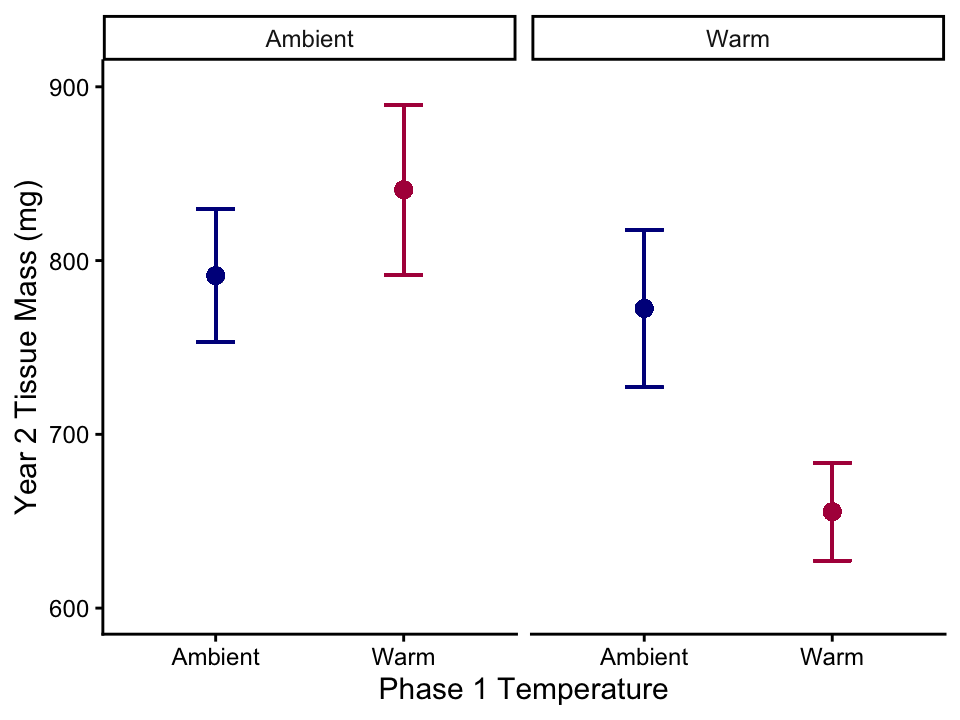

In [15]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_temp, Phase_2.1_temp) %>%
  mutate(
    mean_growth = mean(Actual_tissue_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_temp <- factor(summary_stats_t$Phase_2.1_temp, 
                                        levels = c("Ambient", "Warm"))

ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_temp), 
             labeller = as_labeller(c("Warm" = "Warm", "Ambient" = "Ambient")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Tissue Mass (mg)") +
ylim(600,900)+
  theme(legend.position = "none") # Remove legend

In [11]:
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Warm         Hyp             640 68.0 27.3      501      780
 Ambient      Hyp             738 68.4 27.7      598      878
 Warm         Norm            859 69.3 27.5      717     1001
 Ambient      Norm            827 70.1 28.6      683      970

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate   SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp        -97.6 56.7 18.4  -1.721  0.1020
 Warm Hyp - Warm Norm         -219.2 94.5 25.9  -2.320  0.0285
 Warm Hyp - Ambient Norm      -186.7 97.7 27.9  -1.912  0.0662
 Ambient Hyp - Warm Norm      -121.6 97.4 27.6  -1.249  0.2222
 Ambient Hyp - Ambient Norm    -89.2 95.4 26.8  -0.935  0.3583
 Warm Norm - Ambient Norm       32.5 57.5 18.0   0.565  0.5793

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedo

In [26]:
(859-738)/859

[1] 0.1408615

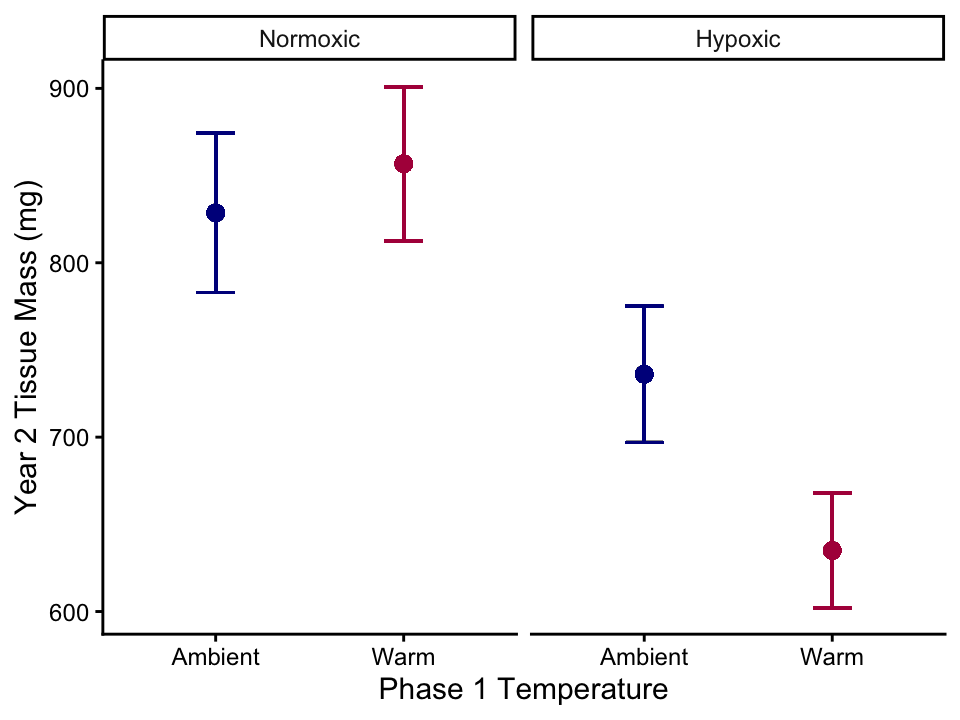

In [25]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_tissue_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_DO <- factor(summary_stats_t$Phase_2.1_DO, 
                                        levels = c("Norm", "Hyp"))

ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Norm" = "Normoxic")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Tissue Mass (mg)") +
  theme(legend.position = "none") # Remove legend

In [29]:
(1003-716)/1003

[1] 0.2861416

In [12]:
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean    SE   df lower.CL upper.CL
 Warm         Warm           Hyp             604  94.8 26.9      410      799
 Ambient      Warm           Hyp             708  94.2 26.1      515      902
 Warm         Ambient        Hyp             676  95.0 27.1      481      871
 Ambient      Ambient        Hyp             767  96.5 28.6      570      965
 Warm         Warm           Norm            716  94.3 26.3      522      910
 Ambient      Warm           Norm            853  94.8 26.9      659     1048
 Warm         Ambient        Norm           1003  99.1 27.9      800     1206
 Ambient      Ambient        Norm            801 101.0 29.7      595     1006

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate    SE   df t.ratio p.value
 Warm Warm Hyp - Ambient Warm Hyp            -104.08  75.6 19.5  -1.377 

In [27]:
Warm Warm Hyp - Warm Ambient Norm           -398.53 135.0 26.3  -2.945  0.0067
    warm both - warm control
Ambient Warm Hyp - Warm Ambient Norm        -294.45 137.0 27.1  -2.153  0.0404
    ambient both - warm control
Warm Ambient Hyp - Warm Ambient Norm        -326.44 135.0 26.4  -2.410  0.0232
    warm hyp - warm cont
Warm Warm Norm - Warm Ambient Norm          -286.58 135.0 26.0  -2.124  0.0434
    warm warm - warm control
Warm Ambient Norm - Ambient Ambient Norm     202.11  80.5 19.6   2.510  0.0210
    warm control - ambient control

ERROR: Error in parse(text = input): <text>:1:6: unexpected symbol
1: Warm Warm
         ^


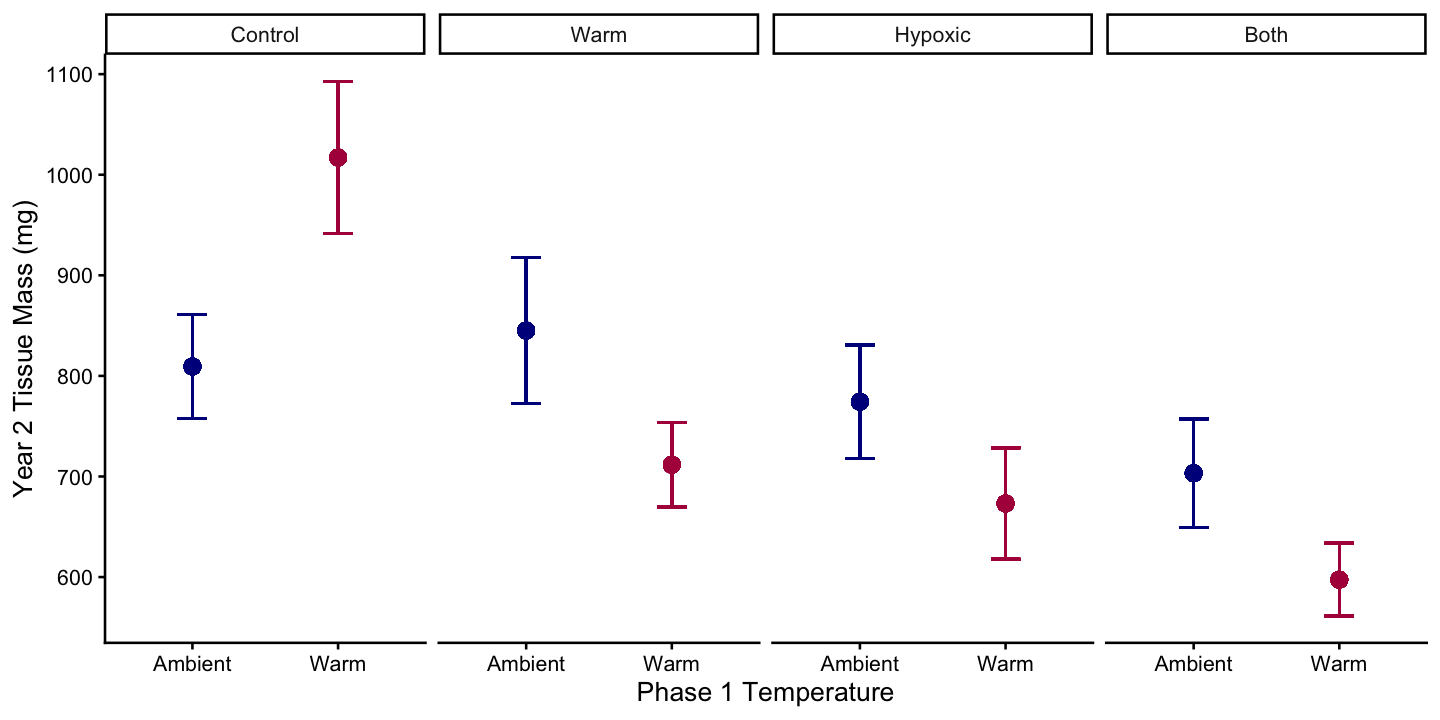

In [17]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO tissue  year 2 
summary_stats_t <- Year2_Growth_clean%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Tissue Mass (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.251771,0.2295028
,457,NA,NA


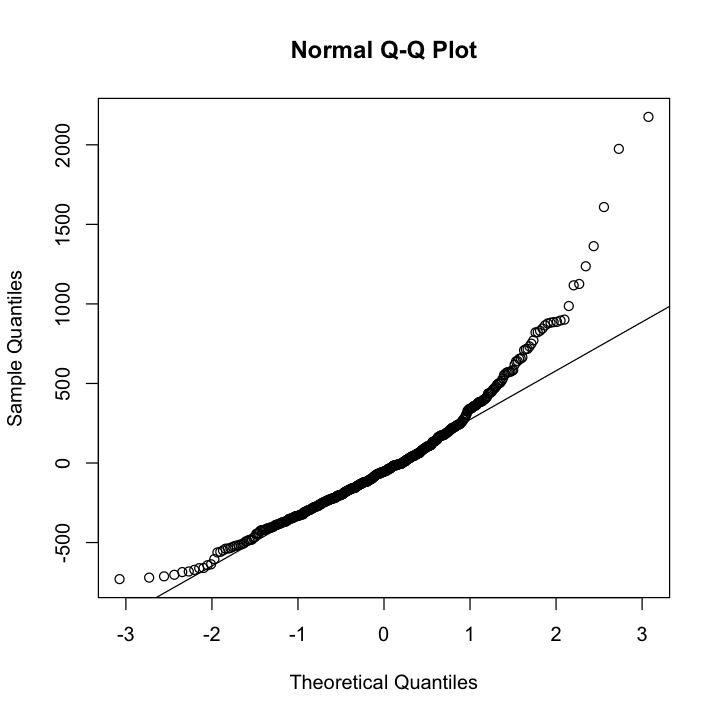

In [28]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#diagnostics
leveneTest(Actual_tissue_year2_mg~Phase_1_treat*Phase_2_treat, Year2_Growth_clean) 
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)

# 2. Shell Mass

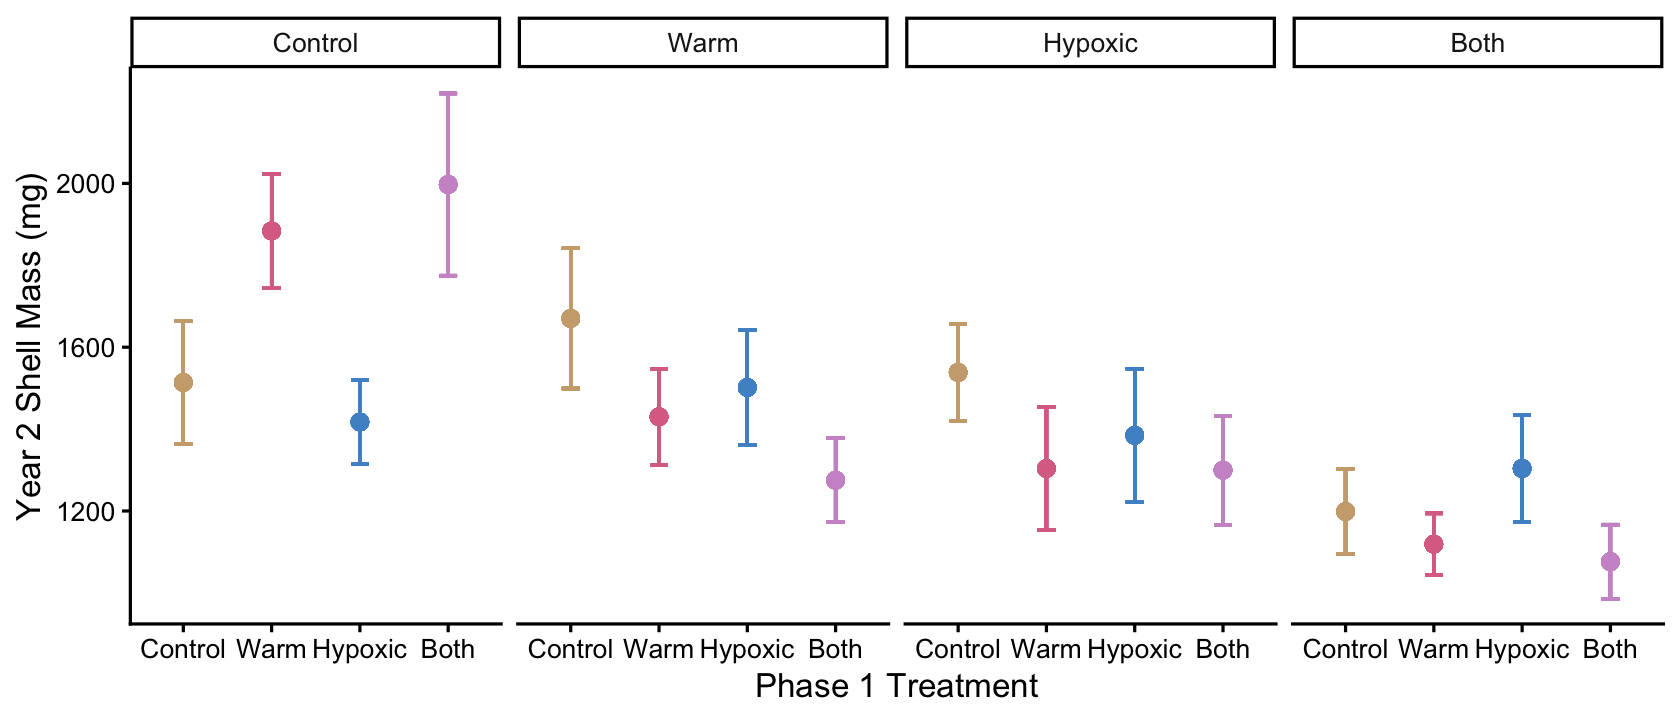

In [32]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_year2_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Shell Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

In [33]:
##tissue growth (mg)
m2 <- lmer(Actual_shell_year2_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
aov_tab <- Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),369.06245801,1,20.06543,0.0000
Phase_1_DO,0.40652687,1,12.98544,0.5348
Phase_1_temp,0.06557657,1,11.15892,0.8025
Phase_2.1_temp,2.21548607,1,19.57775,0.1526
Phase_2.1_DO,4.48587964,1,19.59240,0.0472
Phase_1_DO:Phase_1_temp,0.10553825,1,11.19776,0.7513
Phase_1_DO:Phase_2.1_temp,0.06154471,1,18.78654,0.8068
Phase_1_temp:Phase_2.1_temp,8.04155134,1,18.68702,0.0107
Phase_1_DO:Phase_2.1_DO,0.15338323,1,18.83176,0.6997


In [37]:
#posthocs
emmeans(m2,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean  SE   df lower.CL upper.CL
 Hyp            1281 104 19.8     1065     1497
 Norm           1592 106 20.3     1371     1814

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate  SE   df t.ratio p.value
 Hyp - Norm     -311 147 19.6  -2.118  0.0472

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


In [38]:
(1592-1281)/1592

[1] 0.1953518

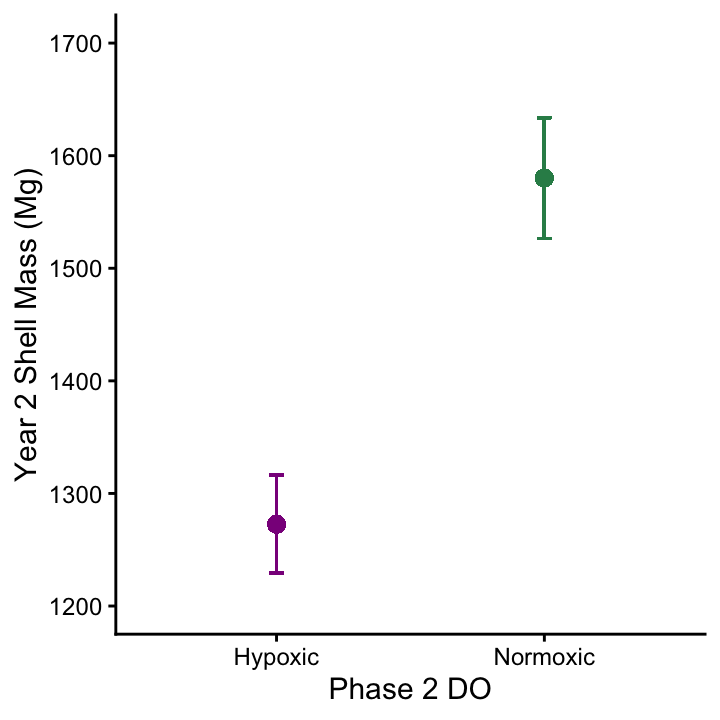

In [42]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#summary stats
summary_stats <- Year2_Growth_clean %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean(Actual_shell_year2_mg, na.rm = TRUE),
    se = std.error(Actual_shell_year2_mg, na.rm = TRUE))
#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Year 2 Shell Mass (Mg)") +
scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
ylim(1200, 1700)+
  theme(legend.position = "none") # Remove legend

In [45]:
#posthocs
emmeans(m2,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp emmean  SE   df lower.CL upper.CL
 Warm         Warm             1231 112 25.9      999     1462
 Ambient      Warm             1424 112 25.7     1193     1655
 Warm         Ambient          1625 116 26.8     1388     1863
 Ambient      Ambient          1467 117 28.4     1226     1707

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                       estimate    SE   df t.ratio p.value
 Warm Warm - Ambient Warm         -193.3  89.6 16.2  -2.157  0.0464
 Warm Warm - Warm Ambient         -394.7 159.0 25.9  -2.484  0.0198
 Warm Warm - Ambient Ambient      -236.2 163.0 27.2  -1.452  0.1579
 Ambient Warm - Warm Ambient      -201.4 161.0 26.3  -1.249  0.2226
 Ambient Warm - Ambient Ambient    -42.9 160.0 26.6  -0.268  0.7910
 Warm Ambient - Ambient Ambient    158.5  94.3 17.5   1.680  0.1106

Results are averaged over the levels of: Phase_1

In [46]:
(1424-1231)/1424

[1] 0.1355337

In [47]:
(1625-1231)/1625

[1] 0.2424615

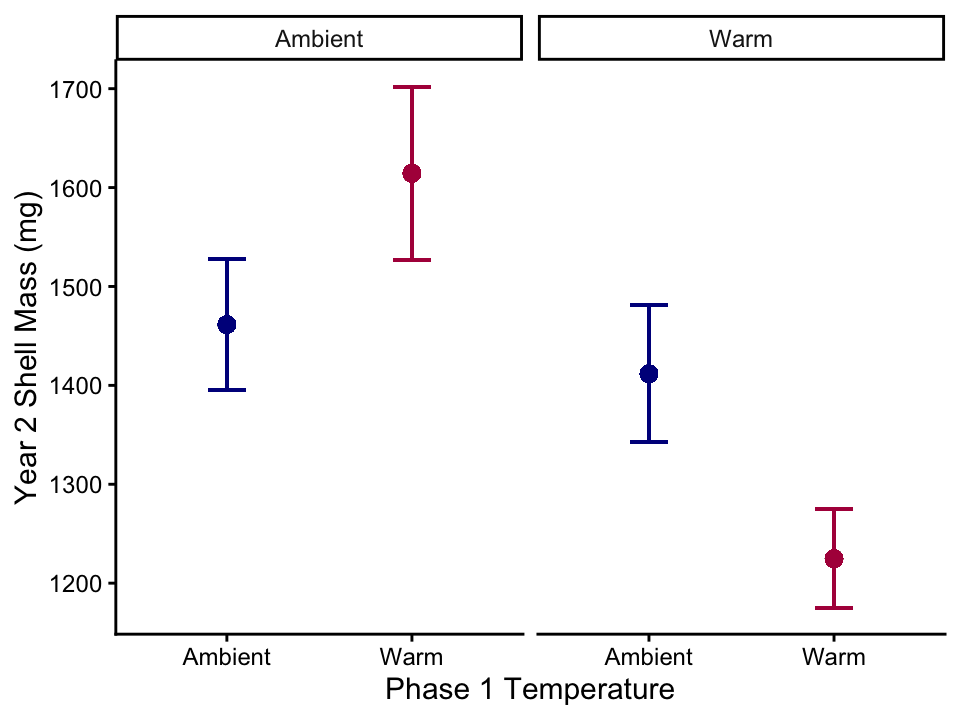

In [44]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_temp, Phase_2.1_temp) %>%
  mutate(
    mean_growth = mean(Actual_shell_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_temp <- factor(summary_stats_t$Phase_2.1_temp, 
                                        levels = c("Ambient", "Warm"))

ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_temp), 
             labeller = as_labeller(c("Warm" = "Warm", "Ambient" = "Ambient")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Shell Mass (mg)") +
  theme(legend.position = "none") # Remove legend

In [50]:
(1650-1206)/1650

[1] 0.2690909

In [49]:
#posthocs
emmeans(m2,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean  SE   df lower.CL upper.CL
 Warm         Hyp            1206 113 26.2      974     1438
 Ambient      Hyp            1356 114 26.6     1122     1589
 Warm         Norm           1650 115 26.4     1413     1886
 Ambient      Norm           1535 116 27.6     1297     1774

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate    SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp         -149  91.3 17.0  -1.633  0.1208
 Warm Hyp - Warm Norm           -443 159.0 25.9  -2.789  0.0098
 Warm Hyp - Ambient Norm        -329 162.0 26.9  -2.027  0.0527
 Ambient Hyp - Warm Norm        -294 162.0 26.5  -1.818  0.0804
 Ambient Hyp - Ambient Norm     -180 160.0 26.7  -1.120  0.2726
 Warm Norm - Ambient Norm        114  92.8 16.7   1.233  0.2347

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-free

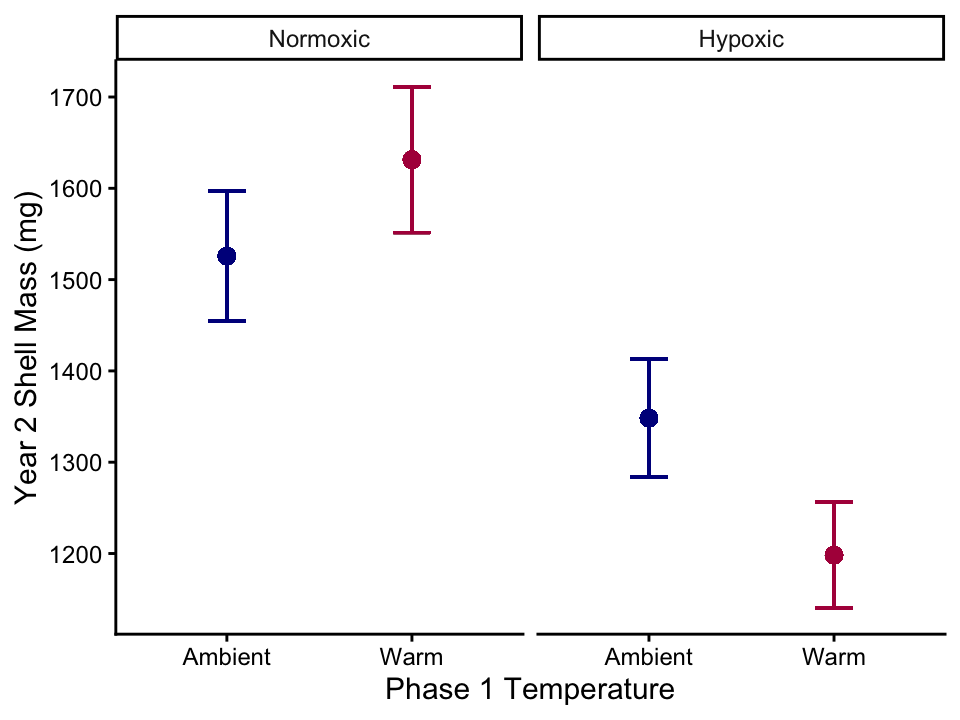

In [48]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_DO <- factor(summary_stats_t$Phase_2.1_DO, 
                                        levels = c("Norm", "Hyp"))

ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Norm" = "Normoxic")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Shell Mass (mg)") +
  theme(legend.position = "none") # Remove legend

In [59]:
(1593-1107)/1593

[1] 0.3050847

In [60]:
(1945-1306)/1945

[1] 0.3285347

In [53]:
#posthocs
emmeans(m2,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean  SE   df lower.CL upper.CL
 Warm         Warm           Hyp            1107 158 26.2      782     1432
 Ambient      Warm           Hyp            1255 157 25.5      931     1579
 Warm         Ambient        Hyp            1306 159 26.4      980     1632
 Ambient      Ambient        Hyp            1456 161 28.0     1126     1787
 Warm         Warm           Norm           1354 158 25.7     1030     1678
 Ambient      Warm           Norm           1593 158 26.2     1268     1919
 Warm         Ambient        Norm           1945 166 27.3     1605     2285
 Ambient      Ambient        Norm           1477 168 29.0     1133     1822

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate  SE   df t.ratio p.value
 Warm Warm Hyp - Ambient Warm Hyp             -147.8 124 18.4  -1.194  0.2475
 Warm Warm Hyp

In [ ]:
 Warm Warm Hyp - Ambient Warm Norm            -486.1 224 26.2  -2.170  0.0393
    warm both - ambient warm
 
Warm Warm Hyp - Warm Ambient Norm            -837.8 228 26.2  -3.683  0.0011
    warm both - warm control
 Ambient Warm Hyp - Warm Ambient Norm         -690.0 229 26.4  -3.020  0.0056
    ambient both - warm cont
 Warm Ambient Hyp - Warm Ambient Norm         -639.1 228 26.3  -2.806  0.0093
    warm hyp - warm cont
 Ambient Ambient Hyp - Warm Ambient Norm      -488.5 231 27.6  -2.112  0.0438
    ambient hyp - warm cont
 Warm Warm Norm - Warm Ambient Norm           -590.5 227 26.0  -2.603  0.0151
    warm warm - warm cont
 Warm Ambient Norm - Ambient Ambient Norm      467.5 132 18.7   3.534  0.0023
    warm cont - ambient cont

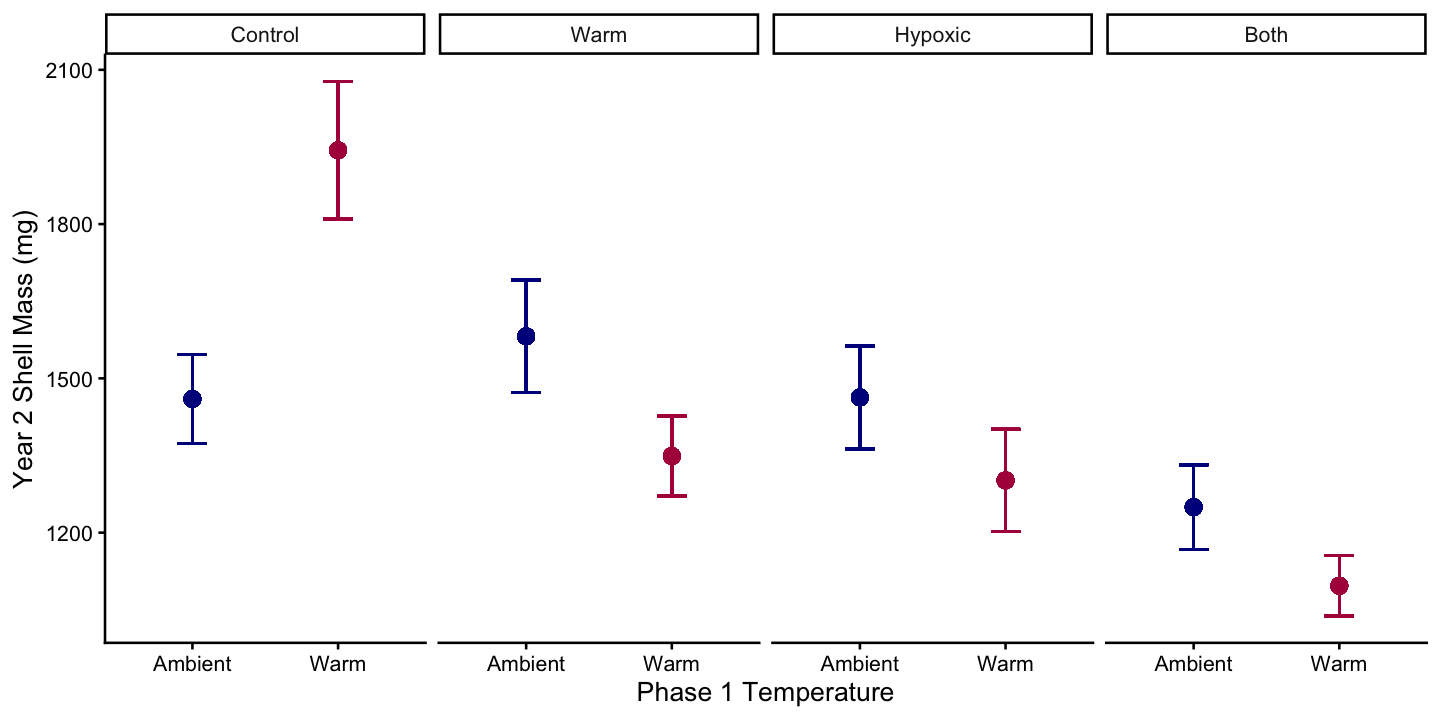

In [51]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot
summary_stats_t <- Year2_Growth_clean%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Shell Mass (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.893311,0.02194206
,457,NA,NA


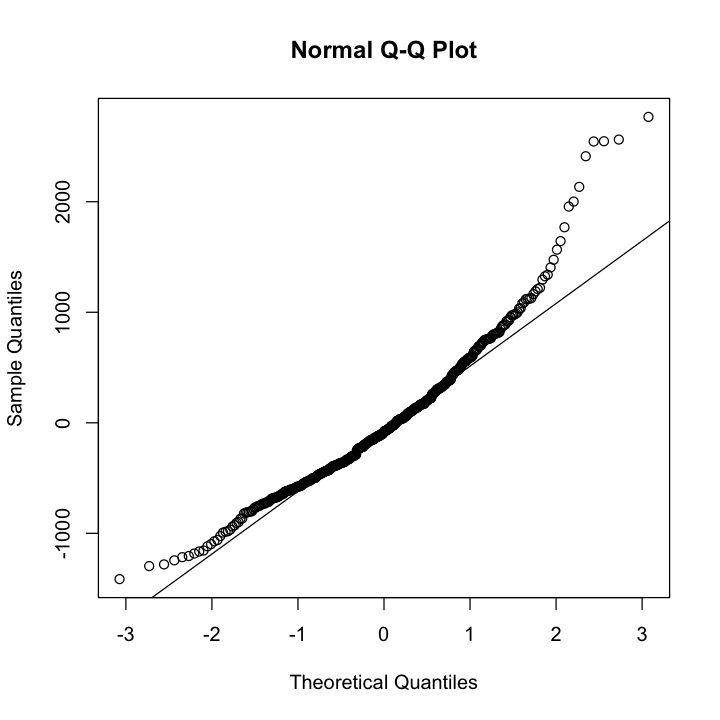

In [54]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#diagnostics
leveneTest(Actual_shell_year2_mg~Phase_1_treat*Phase_2_treat, Year2_Growth_clean) 
m1.e <- residuals(m2)
qqnorm(m1.e)
qqline(m1.e)

# 3. Tissue:Shell Mass

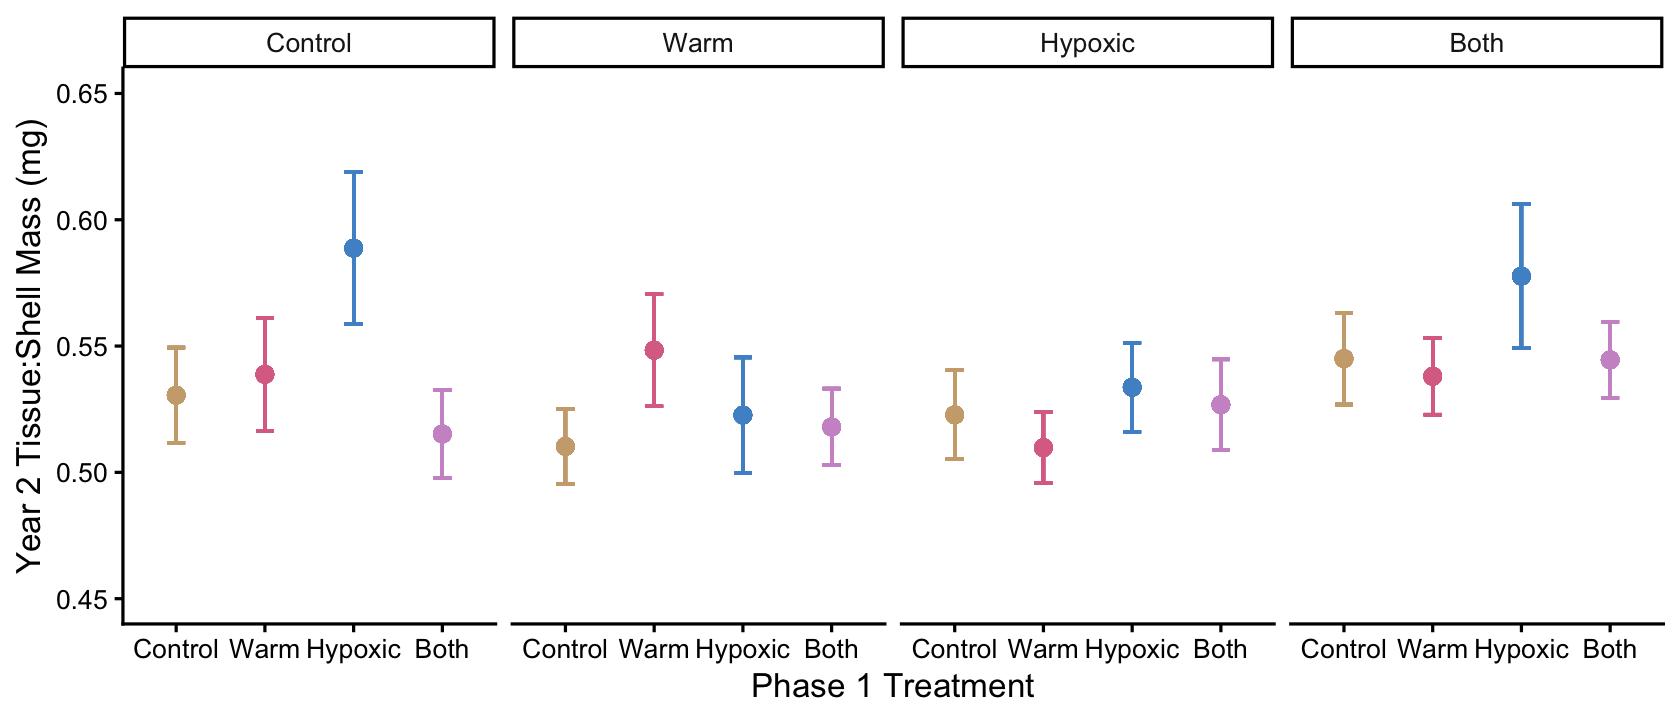

In [57]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean((Actual_tissue_year2_mg/Actual_shell_year2_mg), na.rm = TRUE),
    se_growth = std.error((Actual_tissue_year2_mg/Actual_shell_year2_mg), na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Tissue:Shell Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
ylim(0.45,0.65)+
    theme(legend.position = "none") # Remove legend

In [58]:
m3 <- lmer((Actual_tissue_year2_mg/Actual_shell_year2_mg)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
aov_tab <- Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),4.566100e+03,1,19.30407,0.0000
Phase_1_DO,7.199652e-01,1,13.27302,0.4112
Phase_1_temp,1.045918e+00,1,13.28736,0.3247
Phase_2.1_temp,2.454425e-01,1,19.13609,0.6259
Phase_2.1_DO,1.249904e-01,1,19.18867,0.7275
Phase_1_DO:Phase_1_temp,2.231452e+00,1,13.31544,0.1585
Phase_1_DO:Phase_2.1_temp,2.864812e-01,1,18.60232,0.5988
Phase_1_temp:Phase_2.1_temp,7.901300e-01,1,18.63079,0.3854
Phase_1_DO:Phase_2.1_DO,3.409265e-01,1,18.68040,0.5663
